<a href="https://colab.research.google.com/github/Bendy545/Prague-Rent-Predictor/blob/dev/src/cleaning/prague_rent_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
import pandas as pd
import re


df = pd.read_csv("sreality_combined.csv")
df

,scrape_date,hash_id,name,locality,district,neighborhood,price_czk,size_m2,rooms,floor,...,balcony,terrace,energy_rating,ownership,parking,cellar,loggia,heating,apartment_type,note_about_price
0,2026-02-09,1584403276,Pronájem bytu 4+kk 84 m²,"Slavíkova, Praha 2 - Vinohrady",Praha 2,Vinohrady,50500,84,4+kk,1. podlaží,...,NaN,NaN,Třída F - Velmi nehospodárná č. 264/2020 Sb. p...,Osobní,NaN,NaN,NaN,NaN,NaN,Poplatky za služby + provize 1 měsíční nájem p...
1,2026-02-09,4204737356,Pronájem bytu 2+kk 49 m²,"U nových domů I, Praha - Krč",NaN,NaN,29000,49,2+kk,1. podlaží,...,NaN,NaN,NaN,Družstevní,NaN,6,2,NaN,NaN,NaN
2,2026-02-09,342692684,Pronájem bytu 3+kk 146 m²,"Malešická, Praha",NaN,NaN,46000,146,3+kk,6. podlaží,...,42,NaN,NaN,Osobní,1,6,NaN,NaN,NaN,elektřina se převádí na nájemníka
3,2026-02-09,2642613068,Pronájem bytu 3+kk 121 m²,"Tibetská, Praha - Vokovice",NaN,NaN,40000,121,3+kk,4. podlaží,...,3,12,Třída D - Méně úsporná,Osobní,3,6,NaN,NaN,NaN,poplatky jsou závislé na počtu osob
4,2026-02-09,3349615436,Pronájem bytu 1+kk 114 m² (Loft),"Křížová, Praha 5 - Smíchov",Praha 5,Smíchov,45000,114,1+kk,5. podlaží,...,NaN,NaN,Třída D - Méně úsporná,Osobní,NaN,NaN,NaN,NaN,Loft,elektřina zůstává na majitele zálohy jsou 1800...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6251,2026-03-03,1276016460,Pronájem bytu 5+1 252 m²,"Pařížská, Praha 1 - Josefov",Praha 1,Josefov,1,252,5+1,6. podlaží z celkem 6,...,NaN,True,Třída G - Mimořádně nehospodárná,Osobní,NaN,NaN,NaN,Lokální plynové,NaN,info o ceně v RK
6252,2026-03-03,3390506828,Pronájem bytu 3+kk 74 m²,"Choceradská, Praha 4 - Záběhlice",Praha 4,Záběhlice,28000,74,3+kk,8. podlaží z celkem 11 včetně 3 podzemních,...,NaN,NaN,NaN,Osobní,1,NaN,11,NaN,NaN,NaN
6253,2026-03-03,2946824012,Pronájem bytu 2+kk 50 m²,"Kovářská, Praha 9 - Libeň",Praha 9,Libeň,23000,50,2+kk,2. podlaží,...,5,NaN,NaN,Osobní,1,NaN,NaN,NaN,NaN,"+ 5500,- Kč poplatky + elektřina"
6254,2026-03-03,4088956748,Pronájem bytu 1+kk 33 m²,"Belgická, Praha 2 - Vinohrady",Praha 2,Vinohrady,57000,33,1+kk,2. podlaží z celkem 5,...,NaN,NaN,Třída D - Méně úsporná,Osobní,NaN,NaN,NaN,NaN,NaN,"v ceně internet, recepce"


In [63]:
for col in df.columns:
    filled = df[col].notna().sum()
    if df[col].dtype == 'object':
        filled = df[col].notna().sum() - (df[col] == '').sum()

    pct = filled / len(df) * 100
    bar = '#' * int(pct / 5) + '-' * (20 - int(pct / 5))
    print(f"  {col:<25} [{bar}] {pct:.0f}%  ({filled}/{len(df)})")

  scrape_date               [####################] 100%  (6256/6256)
  hash_id                   [####################] 100%  (6256/6256)
  name                      [####################] 100%  (6256/6256)
  locality                  [####################] 100%  (6256/6256)
  district                  [##################--] 92%  (5731/6256)
  neighborhood              [##################--] 91%  (5678/6256)
  price_czk                 [####################] 100%  (6256/6256)
  size_m2                   [####################] 100%  (6256/6256)
  rooms                     [###################-] 97%  (6091/6256)
  floor                     [####################] 100%  (6256/6256)
  building_type             [####################] 100%  (6256/6256)
  condition                 [####################] 100%  (6256/6256)
  furnished                 [#############-------] 69%  (4345/6256)
  elevator                  [#############-------] 66%  (4130/6256)
  balcony                   [#####-----

# Price statistics

In [64]:
df['price_czk'] = pd.to_numeric(df['price_czk'], errors='coerce')

print(f"Min: {df['price_czk'].min():,.0f} Kc")
print(f"Max: {df['price_czk'].max():,.0f} Kc")
print(f"Average: {df['price_czk'].mean():,.0f} Kc")
print(f"Median: {df['price_czk'].median():,.0f} Kc")
print(f"Price = 1 (placeholder): {(df['price_czk'] == 1).sum()}")
print(f"Price < 3,000 (too low): {(df['price_czk'] < 3000).sum()}")
print(f"Price > 150,000 (too high): {(df['price_czk'] > 150000).sum()}")


Min: 1 Kc
Max: 500,000 Kc
Average: 29,908 Kc
Median: 24,250 Kc
Price = 1 (placeholder): 37
Price < 3,000 (too low): 39
Price > 150,000 (too high): 17


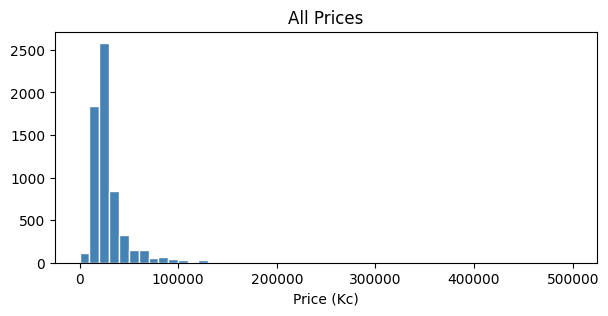

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3))

plt.hist(df['price_czk'].dropna(), bins=50, color='steelblue', edgecolor='white')
plt.title('All Prices')
plt.xlabel('Price (Kc)')

plt.show()



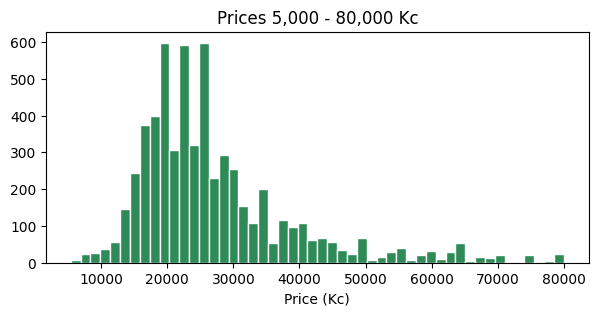

In [66]:
plt.figure(figsize=(7, 3))

reasonable = df[(df['price_czk'] >= 5000) & (df['price_czk'] <= 80000)]['price_czk']
plt.hist(reasonable, bins=50, color='seagreen', edgecolor='white')
plt.title('Prices 5,000 - 80,000 Kc')
plt.xlabel('Price (Kc)')

plt.show()

# How much data does not have a district and dropping them


In [67]:
print(f"Missing district: {(df['district'] == '').sum() + df['district'].isna().sum()}")
df.dropna(subset=['district'], inplace=True)


Missing district: 525


# Checking if there are duplicated data

In [68]:
df.duplicated()

,0
0,False
4,False
5,False
6,False
7,False
...,...
6251,False
6252,False
6253,False
6254,False


# Helper methods for data cleaning

In [69]:
def parse_floor_number(text):
  if pd.isna(text) or text == '':
    return None
  text = str(text).lower().strip()

  if 'přízemí' in text or 'přízemní' in text:
    return 0

  match = re.search(r'(\d+)\.\s*podla', text)
  if match:
    return int(match.group(1))

  return None


def parse_total_floors(text):
  if pd.isna(text) or text == '':
    return None

  match = re.search(r'z\s*celkem\s*(\d+)', str(text))

  if match:
    return int(match.group(1))

  return None

def parse_room_count(rooms_str):
  """
  Convert room string into numeric count
  '2+kk' -> 2 ....
  """
  if pd.isna(rooms_str) or rooms_str == '':
      return None
  rooms_str = str(rooms_str).strip().lower()

  if 'atypick' in rooms_str:
      return None

  match = re.match(r'(\d+)\+(\d+|kk)', rooms_str)
  if match:
      base = int(match.group(1))
      extra = match.group(2)
      if extra == 'kk':
          return base
      else:
          return base + int(extra)

  return None


def parse_has_separate_kitchen(rooms_str):
  """
  This method ckecks if it has a separate kitchen or not
  """
  if pd.isna(rooms_str) or rooms_str == '':
      return None
  rooms_str = str(rooms_str).strip().lower()

  if '+1' in rooms_str or '+2' in rooms_str or '+3' in rooms_str:
      return True
  elif '+kk' in rooms_str:
      return False

  return None



def amenity_to_bool(value):
  """
  Converts amenity field to boolean like balcony, terrace etc. .
  If the field has ANY value -> True
  If NaN/empty -> False
  """
  if pd.isna(value) or str(value).strip() == '':
      return False
  return True


def clean_furnished(value):
  """
  Converts furnished field to Yes / Partially / No / Unknown.
  """
  if pd.isna(value) or str(value).strip() == '':
      return 'Unknown'
  val = str(value).strip().lower()
  if val == 'true' or val == 'ano' or val == 'vybaveno':
      return 'Yes'
  elif 'částečně' in val or 'partial' in val:
      return 'Partially'
  elif val == 'false' or val == 'ne' or val == 'nevybaveno':
      return 'No'
  return 'Unknown'

def clean_elevator(value):
  """
  Convert elevator field Yes / No / Unknown.
  """
  if pd.isna(value) or str(value).strip() == '':
      return 'Unknown'
  val = str(value).strip().lower()
  if val == 'true' or val == 'ano':
      return 'Yes'
  elif val == 'false' or val == 'ne':
      return 'No'
  return 'Unknown'


# Data Cleaning


# 1. Prices


Checking which types each column has

In [33]:
df.dtypes

,0
scrape_date,object
hash_id,int64
name,object
locality,object
district,object
neighborhood,object
price_czk,int64
size_m2,int64
rooms,object
floor,object


In [70]:
df['price_czk'] = pd.to_numeric(df['price_czk'], errors='coerce')
df = df[df['price_czk'].notna()]
df = df[df['price_czk'] != 1]
df = df[(df['price_czk'] >= 5000) & (df['price_czk'] <= 150000)]
print(len(df))

5678


# 2. Size
Filtering size data

In [71]:
df['size_m2'] = pd.to_numeric(df['size_m2'], errors='coerce')
df = df[(df['size_m2'] >= 10) & (df['size_m2'] <= 300)]
print(len(df))

5665


# 3. Rooms

In [72]:
df['room_count'] = df['rooms'].apply(parse_room_count)
df['has_separate_kitchen'] = df['rooms'].apply(parse_has_separate_kitchen)
df = df[df['room_count'].notna()]
df['room_count'] = df['room_count'].astype(int)
print(len(df))

5512


# 4. Floors

In [73]:
df['floor_number'] = df['floor'].apply(parse_floor_number)
df['total_floors'] = df['floor'].apply(parse_total_floors)

df['floor_number']

,floor_number
0,1
4,5
5,3
6,2
7,3
...,...
6250,3
6252,8
6253,2
6254,2


# 5. Amenity (like balcony, terrace, cellar .....)

converting them into booleans. It they are not present == False

In [74]:
df['has_balcony'] = df['balcony'].apply(amenity_to_bool)
df['has_terrace'] = df['terrace'].apply(amenity_to_bool)
df['has_cellar'] = df['cellar'].apply(amenity_to_bool)
df['has_parking'] = df['parking'].apply(amenity_to_bool)

# 8. Cleaning data at furnished and elevator

In [75]:
df['furnished'] = df['furnished'].apply(clean_furnished)
df['elevator'] = df['elevator'].apply(clean_elevator)

# 9. Renaming columns for a new dataset

In [76]:
df.dtypes

,0
scrape_date,object
hash_id,int64
name,object
locality,object
district,object
neighborhood,object
price_czk,int64
size_m2,int64
rooms,object
floor,object


In [77]:
final_columns = [
    'price_czk',
    'district',
    'size_m2',
    'room_count',
    'has_separate_kitchen',
    'floor_number',
    'total_floors',
    'building_type',
    'condition',
    'ownership',
    'furnished',
    'elevator',
    'has_balcony',
    'has_terrace',
    'has_cellar',
    'has_parking',
]

df_clean = df[final_columns].copy()


# Dropping NaN values
only in these 3 columns and the rest leave, just ckecking if there were some mistakes when cleaning

In [79]:
important_cols = ['price_czk', 'size_m2', 'room_count']
df_clean = df_clean.dropna(subset=important_cols)
print(len(df_clean))

5512


# Saving into new cleaned dataset (CSV)

In [80]:
df_clean.to_csv('sreality_cleaned.csv', index=False, encoding='utf-8-sig')